# Import the packages

In [1]:
import pandas as pd
import numpy as np
from scipy.integrate import quad
import scipy.linalg as la
import matplotlib.pyplot as plt
import emcee
import corner
import os
import time
from multiprocess import Pool, cpu_count

# Load Pantheon+SH0ES SNe Data & Covariance

In [2]:
# Load Pantheon SNe dataset
sn_file_path = 'data/Pantheon+SH0ES.dat'
try:
    df_sn = pd.read_csv(sn_file_path, sep=r'\s+')
    N_sn = len(df_sn)
    print(f"SNe Dataset loaded successfully. Total supernovae: {N_sn}")
except FileNotFoundError:
    print(f"Error: The file {sn_file_path} was not found.")

# Load Covariance Matrix
cov_file_path = 'data/Pantheon+SH0ES_STAT+SYS.cov' 
try:
    with open(cov_file_path, 'r') as f:
        lines = f.readlines()
    if len(lines[0].split()) == 1:
        lines = lines[1:]
        
    cov_1d = np.loadtxt(lines)
    C = cov_1d.reshape((N_sn, N_sn))
    
    # Cholesky decomposition
    c_chol, lower = la.cho_factor(C)
    C_inv = la.cho_solve((c_chol, lower), np.eye(N_sn))
    log_det_C = 2.0 * np.sum(np.log(np.diag(c_chol)))
    print("SNe Covariance matrix loaded and inverted.")
except FileNotFoundError:
    print(f"Error: The file {cov_file_path} was not found.")

SNe Dataset loaded successfully. Total supernovae: 1701
SNe Covariance matrix loaded and inverted.


# Load Cosmic Chronometers Data

In [3]:
cc_file_path = 'data/CC.txt'

try:
    # Most CC data files are space or tab separated
    df_cc = pd.read_csv(cc_file_path, sep=r'\s+')
    
    # Verify required columns exist
    required_cc_cols = ['z', 'Hz', 'err_Hz']
    missing = [col for col in required_cc_cols if col not in df_cc.columns]
    
    if not missing:
        print(f"CC Dataset loaded successfully. Total data points: {len(df_cc)}")
        display(df_cc.head())
    else:
        print(f"Warning: Missing expected columns {missing}. Please rename columns to match: {required_cc_cols}")

except FileNotFoundError:
    print(f"Error: The file {cc_file_path} was not found.")
    
    # --- FALLBACK MOCK DATA just so the code compiles if you don't have the file yet ---
    print("Creating a temporary mock CC dataset for testing purposes...")
    mock_data = {
        'z': [0.07, 0.12, 0.20, 0.28, 0.35],
        'Hz': [69.0, 71.3, 75.0, 78.8, 82.7],
        'err_Hz': [1.9, 2.1, 2.5, 3.0, 3.5]
    }
    df_cc = pd.DataFrame(mock_data)

CC Dataset loaded successfully. Total data points: 32


,z,Hz,err_Hz
0,0.070,69.0,19.6
1,0.090,69.0,12.0
2,0.120,68.6,26.2
3,0.170,83.0,8.0
4,0.179,75.0,4.0


# Theoretical Physics Models

In [4]:
c = 299792.458 # km/s

# ---- SNe Models ----
def model_calibrators(M_B, mu_ceph):
    return M_B + mu_ceph

def E_inverse(z, Omega_m):
    Omega_L = 1.0 - Omega_m
    return 1.0 / np.sqrt(Omega_m * (1 + z)**3 + Omega_L)

def luminosity_distance_mpc(z_hel, z_cmb, H_0, Omega_m):
    integral, _ = quad(E_inverse, 0, z_cmb, args=(Omega_m,))
    return (c / H_0) * (1 + z_hel) * integral

def model_cosmology(z_hel, z_cmb, M_B, H_0, Omega_m):
    d_L_mpc = luminosity_distance_mpc(z_hel, z_cmb, H_0, Omega_m)
    return M_B + 5.0 * np.log10(d_L_mpc) + 25.0

# ---- CC Model ----
def H_LCDM(z, Omega_m, H_0):
    """Theoretical prediction for H(z) in a flat LCDM universe."""
    Omega_L = 1.0 - Omega_m
    return H_0 * np.sqrt(Omega_m * (1 + z)**3 + Omega_L)

# Joint Likelihood Construction

In [5]:
def log_prior(params):
    Omega_m, H_0, M_B = params
    if (0.01 < Omega_m < 0.99) and (50.0 < H_0 < 100.0) and (-21.0 < M_B < -18.0):
        return 0.0
    return -np.inf

# 1. Supernova Likelihood
def log_likelihood_sn(params, data_sn, C_inv, log_det_C):
    Omega_m, H_0, M_B = params
    delta = np.zeros(len(data_sn))
    
    for i, row in data_sn.iterrows():
        m_b_obs = row['m_b_corr']
        if row['IS_CALIBRATOR'] == 1 and row['CEPH_DIST'] > -9:
            m_b_th = model_calibrators(M_B, row['CEPH_DIST'])
        else:
            m_b_th = model_cosmology(row['zHEL'], row['zCMB'], M_B, H_0, Omega_m)
        delta[i] = m_b_obs - m_b_th
        
    chi2 = np.dot(delta.T, np.dot(C_inv, delta))
    return -0.5 * (chi2 + log_det_C + len(data_sn) * np.log(2 * np.pi))

# 2. Cosmic Chronometer Likelihood
def log_likelihood_cc(params, data_cc):
    Omega_m, H_0, M_B = params
    chi2_cc = 0.0
    
    # CC constrains only Omega_m and H_0. It does not depend on M_B.
    for i, row in data_cc.iterrows():
        H_th = H_LCDM(row['z'], Omega_m, H_0)
        chi2_cc += ((row['Hz'] - H_th) ** 2) / (row['err_Hz'] ** 2)
        
    return -0.5 * chi2_cc

# 3. Joint Log Posterior
def log_posterior_joint(params, data_sn, C_inv, log_det_C, data_cc):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    
    ll_sn = log_likelihood_sn(params, data_sn, C_inv, log_det_C)
    ll_cc = log_likelihood_cc(params, data_cc)
    
    # ln L_joint = ln L_SN + ln L_CC
    return lp + ll_sn + ll_cc

# Run Joint MCMC Analysis

In [6]:
os.environ["OMP_NUM_THREADS"] = "1"

ndim = 3
nwalkers = 36
best_fit_guess = np.array([0.33, 73.0, -19.24])
initial_pos = best_fit_guess + 1e-4 * np.random.randn(nwalkers, ndim)

filename = "pantheon_cc_mcmc_chain.h5"
backend = emcee.backends.HDFBackend(filename)
backend.reset(nwalkers, ndim)

nsteps = 1000

# Leave 2 cores free for system responsiveness
ncpu = max(1, cpu_count() - 2)
print(f"Detected {cpu_count()} CPU cores. Setting up pool with {ncpu} cores...")

start_time = time.time()
with Pool(processes=ncpu) as pool:
    sampler = emcee.EnsembleSampler(
        nwalkers, 
        ndim, 
        log_posterior_joint, 
        args=(df_sn, C_inv, log_det_C, df_cc),
        pool=pool,          
        backend=backend
    )

    print(f"Running JOINT MCMC for {nsteps} steps...")
    sampler.run_mcmc(initial_pos, nsteps, progress=True)

end_time = time.time()
print(f"\nMCMC run complete. Time taken: {(end_time - start_time) / 60:.2f} minutes.")

Detected 20 CPU cores. Setting up pool with 18 cores...
Running JOINT MCMC for 1000 steps...


100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [44:32<00:00,  2.67s/it]


MCMC run complete. Time taken: 44.60 minutes.


# Process Results and Plot Joint Corner


--- JOINT Parameter Constraints (Median ± 1-sigma) ---
$\Omega_m$: 0.3287 +0.0162 / -0.0161
$H_0$: 71.4427 +0.8583 / -0.8148
$M_B$: -19.2990 +0.0251 / -0.0233


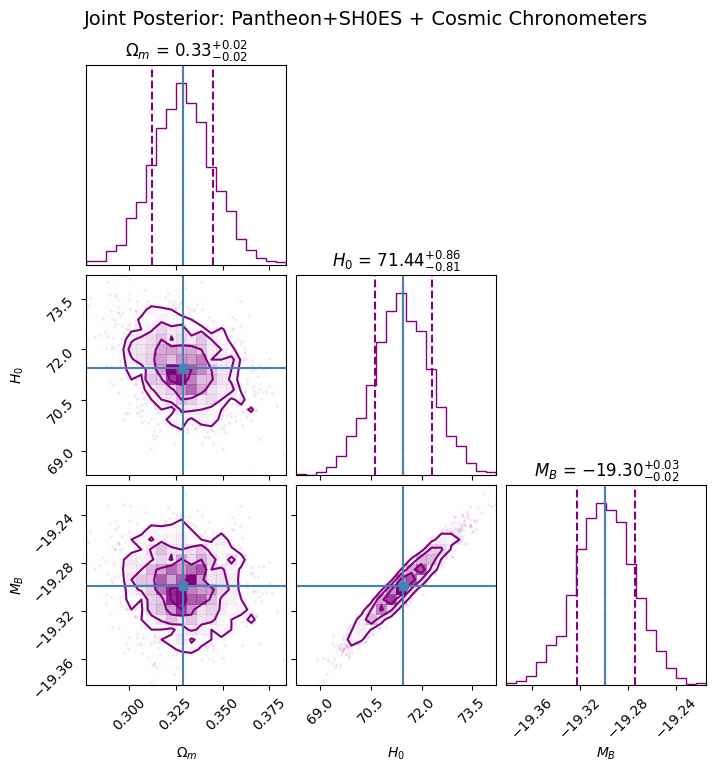

In [7]:
discard_steps = 300
thin_steps = 15
flat_samples = sampler.get_chain(discard=discard_steps, thin=thin_steps, flat=True)

labels = [r"$\Omega_m$", r"$H_0$", r"$M_B$"]
results = {}

print("\n--- JOINT Parameter Constraints (Median ± 1-sigma) ---")
for i in range(ndim):
    mcmc_samples = flat_samples[:, i]
    median = np.percentile(mcmc_samples, 50)
    lower = median - np.percentile(mcmc_samples, 16)
    upper = np.percentile(mcmc_samples, 84) - median
    results[labels[i]] = median
    print(f"{labels[i]}: {median:.4f} +{upper:.4f} / -{lower:.4f}")

fig = corner.corner(
    flat_samples, 
    labels=labels, 
    truths=[results[r"$\Omega_m$"], results[r"$H_0$"], results[r"$M_B$"]],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12},
    color='purple' # Differentiate from Week 5 plots
)
plt.suptitle("Joint Posterior: Pantheon+SH0ES + Cosmic Chronometers", y=1.02, fontsize=14)
plt.show()

# Extract best fit for next plot
best_Omega_m = results[r"$\Omega_m$"]
best_H0 = results[r"$H_0$"]

# Plot H(z) Prediction vs Data

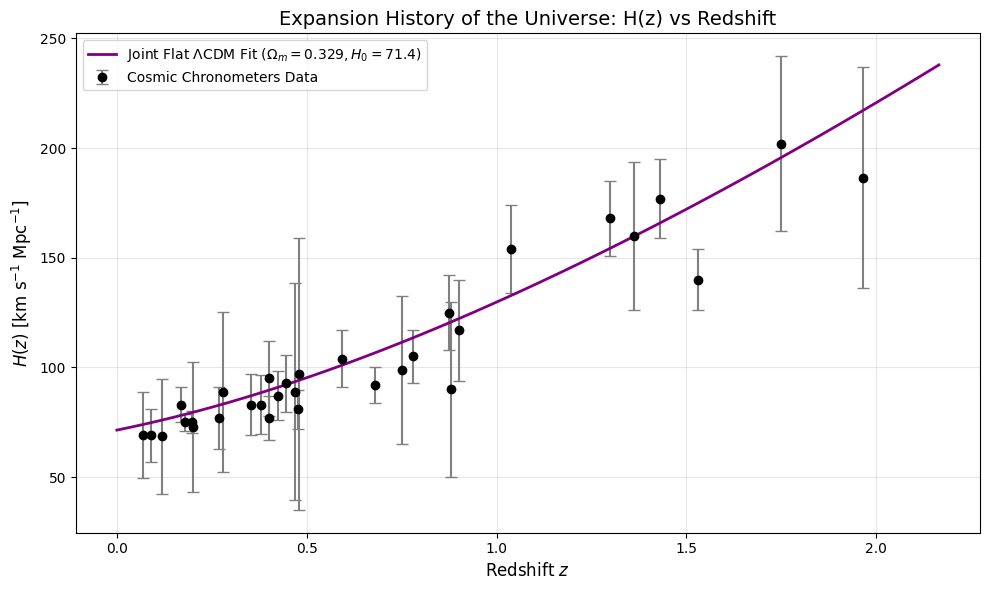

In [8]:
plt.figure(figsize=(10, 6))

# Plot the Cosmic Chronometer Data Points
plt.errorbar(
    df_cc['z'], 
    df_cc['Hz'], 
    yerr=df_cc['err_Hz'], 
    fmt='o', 
    color='black', 
    ecolor='gray', 
    capsize=4, 
    label='Cosmic Chronometers Data'
)

# Create a smooth theoretical curve using the joint best-fit parameters
z_range = np.linspace(0, max(df_cc['z']) + 0.2, 100)
H_theory = [H_LCDM(z, best_Omega_m, best_H0) for z in z_range]

plt.plot(
    z_range, 
    H_theory, 
    color='purple', 
    lw=2, 
    label=rf'Joint Flat $\Lambda$CDM Fit ($\Omega_m={best_Omega_m:.3f}, H_0={best_H0:.1f}$)'
)

plt.title('Expansion History of the Universe: H(z) vs Redshift', fontsize=14)
plt.xlabel('Redshift $z$', fontsize=12)
plt.ylabel('$H(z)$ [km s$^{-1}$ Mpc$^{-1}$]', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()